#### **Notebook #2**
The notebook describes steps required for denoising sigma0 observation from Sentinel-1 using ESA or NERSC algorithm 

In [14]:
%load_ext autoreload
%autoreload 2

from s1denoise.tools import run_correction
from openwind.sar_data import db2linear, preprocess_sar_data, export2netcdf
from nansat import Nansat
import matplotlib.pyplot as plt
import xarray as xr
import pythesint as pti
from pathlib import Path
import pythesint as pti

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Specify if additional denoise is required or not
calibrate = True    

# Define path/to/product.SAFE(zip)
src = Path('/src/.devcontainer/S1A_IW_GRDH_1SDV_20200212T004113_20200212T004141_031212_0396DD_43D4.zip')

In [17]:
# Apply denoisin
s1_corr = preprocess_sar_data(src, dst_px_size=300)

>> Processing /src/.devcontainer/S1A_IW_GRDH_1SDV_20200212T004113_20200212T004141_031212_0396DD_43D4.zip
>> Remove noise from sigma0
Correct VH band
Correct VV band
>> Resizing image to 300 m


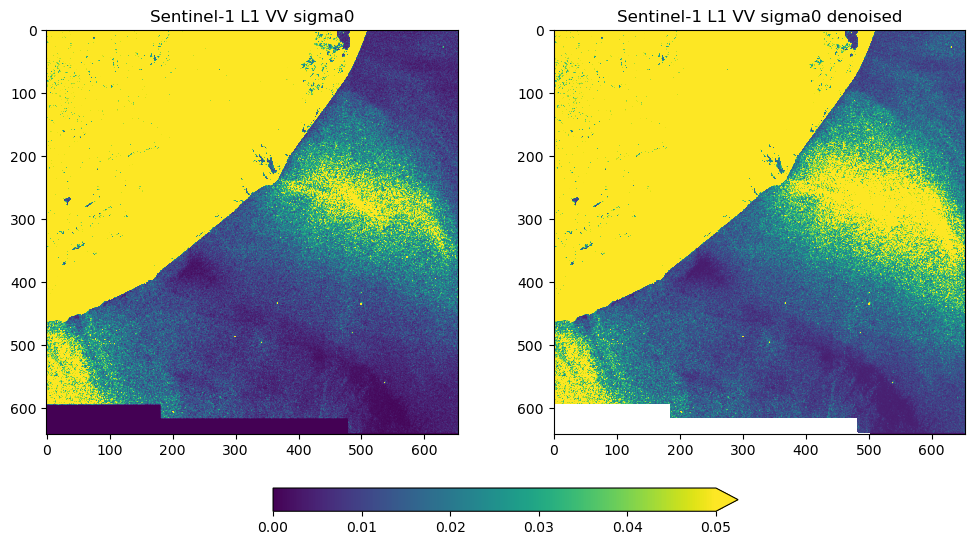

In [18]:
%matplotlib inline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
ax1.set_title('Sentinel-1 L1 VV sigma0')
im1 = ax1.imshow(s1_corr['sigma0_VV'][:, 100:-100], clim=(0, 0.05), cmap='viridis')
ax2.set_title('Sentinel-1 L1 VV sigma0 denoised')
im2 = ax2.imshow(db2linear(s1_corr['sigma0_vv_denoised'][:, 100:-100]), clim=(0, 0.05), cmap='viridis')

plt.colorbar(im1, ax=[ax1,ax2], orientation='horizontal', shrink=0.5, pad=0.1, extend='max')
plt.show()

In [19]:
uri = export2netcdf(s1_corr)

>> Fetch geolocation grids and watermask
>> Prepare dataset
>> Write to: S1A_IW_GRDH_1SDV_20200212T004113_20200212T004141_031212_0396DD_43D4.nc


In [21]:


# Set up metadata and save to separate object
incidence_meta = pti.get_cf_standard_name('angle_of_incidence')
incidence_meta['_FillValue'] = -999.

lon_meta = pti.get_cf_standard_name('longitude')
lon_meta['_FillValue'] = -999.

lat_meta = pti.get_cf_standard_name('latitude')
lat_meta['_FillValue'] = -999.  

look_meta = {'_FillValue': -999.}
                    
                    
             
ds = xr.Dataset(attrs=n.get_metadata(), 
                coords=dict(
                    lat=(('row', 'col'), lats_grd, lat_meta),
                    lon=(('row', 'col'), lon_grd, lon_meta)),                  
                data_vars=dict( 
                    sigma0_s1dn=(('row', 'col'), db2linear(s1_corr['sigma0_VV']), {'polarization': 'VV', '_FillValue': -999.}),
                    sigma0=(('row', 'col'), n['sigma0_VV'], {'polarization': 'VV', '_FillValue': -999.}),
                    angle_of_incidence=(('row', 'col'), n['incidence_angle'], incidence_meta,),
                    look_direction=(('row', 'col'), n['look_direction'], look_meta),
                    watermask=(('row', 'col'), watermask[1], {'source': 'MOD44W', '_FillValue': -999.})
                ))

dst_path = Path(n.name).with_suffix('.nc')
if dst_path.exists(): dst_path.unlink()
ds.to_netcdf(Path(n.name).with_suffix('.nc'))
ds.close()